In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/featured_uhi_v2.csv")

FEATURES = ["NDVI", "NDBI", "Elevation", "Population"]
model = joblib.load("../outputs/lst_model_xgb_v3.pkl")
print("Data and model loaded")

Data and model loaded


In [3]:
# Same spatial zones used in training (coords for grouping, not prediction)
n_bins = 10
df["lat_bin"] = pd.cut(df["Latitude"], bins=n_bins, labels=False)
df["lon_bin"] = pd.cut(df["Longitude"], bins=n_bins, labels=False)
df["zone"] = df["lat_bin"].astype(str) + "_" + df["lon_bin"].astype(str)

X = df[FEATURES]
df["LST_baseline"] = model.predict(X)
print(f"Baseline city mean LST: {df['LST_baseline'].mean():.2f} C")

Baseline city mean LST: 43.46 C


In [4]:
# Intervention 1: Urban greening (more vegetation + less built-up)
green = X.copy()
green["NDVI"] = (green["NDVI"] * 1.20).clip(upper=1.0)
green["NDBI"] = green["NDBI"] * 0.85
df["LST_greening"] = model.predict(green)

# Intervention 2: Cool / permeable surfaces (reduce built-up signal)
cool = X.copy()
cool["NDBI"] = cool["NDBI"] * 0.75
df["LST_coolsurface"] = model.predict(cool)

# Cooling achieved per point (positive = cooler)
df["cooling_greening"]    = df["LST_baseline"] - df["LST_greening"]
df["cooling_coolsurface"] = df["LST_baseline"] - df["LST_coolsurface"]

print(f"Mean cooling - greening     : {df['cooling_greening'].mean():.3f} C")
print(f"Mean cooling - cool surface : {df['cooling_coolsurface'].mean():.3f} C")

Mean cooling - greening     : 0.383 C
Mean cooling - cool surface : 0.121 C


In [5]:
zone_summary = df.groupby("zone").agg(
    n_points         = ("LST_baseline", "size"),
    LST_baseline     = ("LST_baseline", "mean"),
    cooling_greening = ("cooling_greening", "mean"),
    cooling_cool     = ("cooling_coolsurface", "mean"),
    Latitude         = ("Latitude", "mean"),
    Longitude        = ("Longitude", "mean")
).reset_index()

hot_threshold = zone_summary["LST_baseline"].quantile(0.90)
zone_summary["is_hotspot"] = zone_summary["LST_baseline"] >= hot_threshold

print(f"Hotspot zone threshold: {hot_threshold:.2f} C")
print(f"Hotspot zones: {zone_summary['is_hotspot'].sum()} of {len(zone_summary)}")

Hotspot zone threshold: 45.08 C
Hotspot zones: 10 of 96


In [6]:
zone_summary["best_cooling"] = zone_summary[
    ["cooling_greening", "cooling_cool"]
].max(axis=1)

zone_summary["best_strategy"] = np.where(
    zone_summary["cooling_greening"] >= zone_summary["cooling_cool"],
    "Greening",
    "Cool surfaces"
)

priority = (
    zone_summary[zone_summary["is_hotspot"]]
    .sort_values("best_cooling", ascending=False)
    .reset_index(drop=True)
)
priority.index = priority.index + 1   # rank starts at 1

priority[["zone", "LST_baseline", "best_cooling", "best_strategy", "n_points"]].head(10)

,zone,LST_baseline,best_cooling,best_strategy,n_points
1,6_3,45.272572,0.838862,Greening,90
2,7_2,45.375313,0.695621,Greening,140
3,3_9,46.198212,0.692642,Greening,116
4,8_9,45.194153,0.686841,Greening,16
5,4_9,45.331989,0.635874,Greening,103
6,7_7,45.084743,0.632095,Greening,120
7,6_2,45.418404,0.621105,Greening,109
8,7_8,45.206871,0.619098,Greening,107
9,6_7,45.224529,0.556578,Greening,104
10,2_9,45.376434,0.551216,Greening,109


Saved -> outputs/reports/intervention_priority.csv


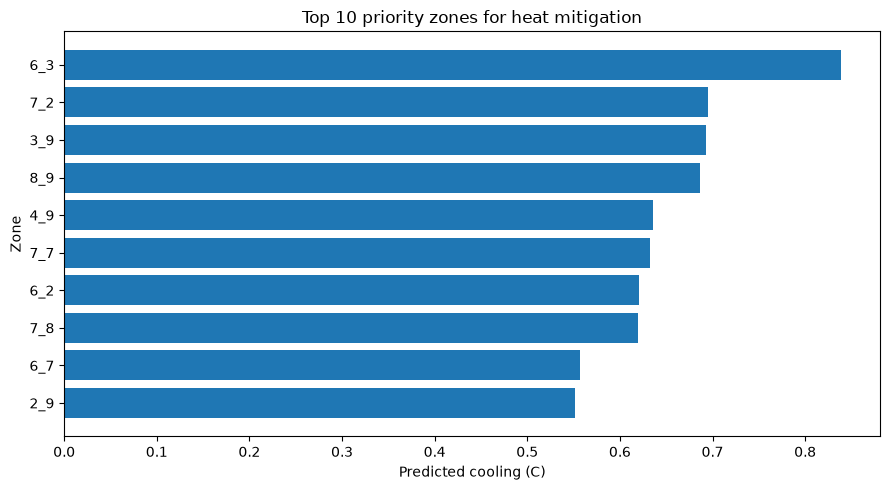

In [7]:
priority.to_csv("../outputs/reports/intervention_priority.csv", index=False)
print("Saved -> outputs/reports/intervention_priority.csv")

top10 = priority.head(10)
plt.figure(figsize=(9,5))
plt.barh(top10["zone"][::-1], top10["best_cooling"][::-1])
plt.xlabel("Predicted cooling (C)")
plt.ylabel("Zone")
plt.title("Top 10 priority zones for heat mitigation")
plt.tight_layout()
plt.show()